# Methods for minimizing a bidimensional function

In [4]:
using Pkg
ENV["PYTHON"] = ""
Pkg.build("PyCall")

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`
Precompiling packages...
  14229.7 ms  ✓ PyCall
  1 dependency successfully precompiled in 16 seconds. 203 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version. Otherwise, loading dependents of this package may trigger further precompilation to work with the unexpected version.


In [10]:
using ForwardDiff
using LinearAlgebra

function newton(f, x0::AbstractVector, eps::Real, max_iter::Int = 1000)
  x = copy(x0) 
  k = 1
  
  while k <= max_iter
    grad = ForwardDiff.gradient(f, x)
    H = ForwardDiff.hessian(f, x)
    
    lambda = 1e-6
    while !isposdef(H)
      H = H + lambda * I
      lambda *= 10
    end
    
    step = -(H \ grad)
    x_new = x + step
    
    grad_new = ForwardDiff.gradient(f, x_new)
    if norm(grad_new) < eps
      return (xmin = x_new, fmin = f(x_new), iterations = k)
    end
    
    x = x_new
    k += 1
  end
  
  return (xmin = x, fmin = f(x), iterations = max_iter)
end

newton (generic function with 2 methods)

### Comparison and plotting of all methods

In [11]:
using Plots
using Printf
using BenchmarkTools

function calculate_min_2d(alg, alg_name, f, x0, eps = 1e-4)
  result = alg(f, x0, eps)

  @printf("\n%s method: ", alg_name)
  @btime $alg($f, $x0, $eps)
  @printf("Minimum found at: x ~= [%.4f, %.4f]\n", result.xmin[1], result.xmin[2])
  @printf("With f(x) min ~= %.5e in %d iterations\n", result.fmin, result.iterations)

  x1_vals = range(min(x0[1], result.xmin[1]) - 1, max(x0[1], result.xmin[1]) + 1, length=100)
  x2_vals = range(min(x0[2], result.xmin[2]) - 1, max(x0[2], result.xmin[2]) + 1, length=100)
  
  f_plot(x, y) = f([x, y])
  p = contour(x1_vals, x2_vals, f_plot, levels=30, color=:viridis, xlabel="x1", ylabel="x2")

  scatter!(p, [x0[1]], [x0[2]], color=:blue, label="Start x0", markersize=4)
  scatter!(p, [result.xmin[1]], [result.xmin[2]], color=:red, label="Min found", markershape=:star5, markersize=6)

  annotate!(p, result.xmin[1], result.xmin[2], text("  Min", :left, :bottom, 8))
  
  return p
end

calculate_min_2d (generic function with 2 methods)

### Results for different functions and intervals


----------------------------------------
EVALUATING: Newton (eps = 0.1)
----------------------------------------

Newton method:   2.488 μs (38 allocations: 1.88 KiB)
Minimum found at: x ~= [0.0000, 0.0000]
With f(x) min ~= 0.00000e+00 in 1 iterations


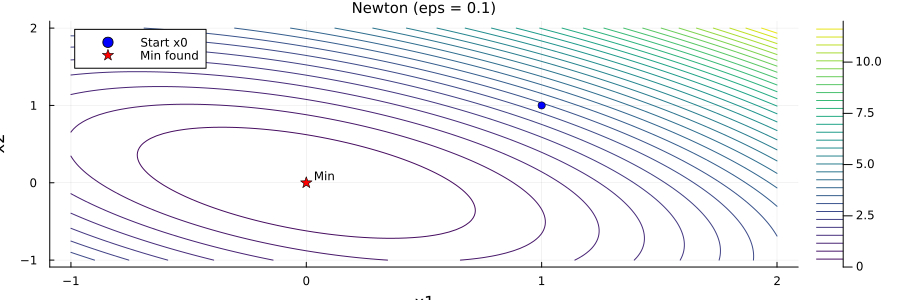

In [14]:
f_target(x) = x[1]^2 + x[2]^2 + x[1] * x[2]
x_init = [1.0, 1.0]

test_cases = [
  (name="Newton (eps = 0.1)",    alg=newton, f=f_target, x0=x_init, eps=0.1),
  ]

all_plots = []

for tc in test_cases
  println("\n" * "-"^40)
  println("EVALUATING: $(tc.name)")
  println("-"^40)
  
  p = calculate_min_2d(tc.alg, "Newton", tc.f, tc.x0, tc.eps)
  
  title!(p, tc.name, titlefontsize=10) 
  
  push!(all_plots, p)
end

n_cols = 2
n_rows = ceil(Int, length(test_cases) / n_cols)

plot(all_plots..., layout=(n_rows, n_cols), size=(900, 300 * n_rows))